# 🚀 Trade Promotion Effectiveness Analyzer
### FMCG Promotion Lift & ROI Analysis | India Beverages & Snacks | FY 2023

---

**Business Question:** Are our trade promotions actually driving incremental sales, or are customers simply buying what they would have bought anyway at a lower price?

This is one of the most common and valuable analyses in FMCG retail analytics — measuring **promotional lift** (how much extra volume a promotion generates above baseline) and **ROI** (whether the incremental revenue justifies the discount cost).

**Dataset:** 6,656 weekly transaction records across 8 SKUs, 4 regions, 4 channels, and 6 promotion types over FY 2023.

---


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ─── Custom dark theme matching portfolio brand colors ───
plt.rcParams['figure.facecolor'] = '#0D1B2A'
plt.rcParams['axes.facecolor'] = '#0F2233'
plt.rcParams['axes.edgecolor'] = '#2A3F54'
plt.rcParams['axes.labelcolor'] = '#E0E0E0'
plt.rcParams['xtick.color'] = '#AAAAAA'
plt.rcParams['ytick.color'] = '#AAAAAA'
plt.rcParams['text.color'] = '#E0E0E0'
plt.rcParams['grid.color'] = '#1B4F72'
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 11

# Brand palette
NAVY   = '#0D1B2A'
CYAN   = '#00B4D8'
GOLD   = '#F4A261'
GREEN  = '#2ECC71'
AMBER  = '#F39C12'
RED    = '#E74C3C'
PURPLE = '#9B59B6'
GRAY   = '#7F8C8D'

palette = [CYAN, GOLD, GREEN, AMBER, RED, PURPLE, '#3498DB', '#E67E22']

print("Libraries loaded. Dark theme configured.")

Libraries loaded. Dark theme configured.


## 1. Load & Inspect Data

In [2]:
df = pd.read_csv('promotion_sales_data.csv', parse_dates=['week_date'])
df['is_promo'] = df['is_promo'].astype(bool)

print(f"Shape: {df.shape}")
print(f"Date range: {df['week_date'].min().date()} to {df['week_date'].max().date()}")
print(f"SKUs: {df['sku'].nunique()}  |  Regions: {df['region'].nunique()}  |  Channels: {df['channel'].nunique()}")
df.head()

Shape: (6656, 17)
Date range: 2023-01-02 to 2023-12-25
SKUs: 8  |  Regions: 4  |  Channels: 4


,row_id,week_date,month,sku,category,region,channel,promo_type,discount_pct,baseline_units,actual_units_sold,selling_price,revenue,promo_cost,incremental_units,incremental_revenue,is_promo
0,1,2023-01-02,1,Cola 500ml,Carbonated Drinks,North India,Modern Trade,No Promotion,0,1867.8,1867,45.0,84015.0,0.0,0.00,0.00,False
1,2,2023-01-09,1,Cola 500ml,Carbonated Drinks,North India,Modern Trade,No Promotion,0,1616.6,1616,45.0,72720.0,0.0,0.00,0.00,False
2,3,2023-01-16,1,Cola 500ml,Carbonated Drinks,North India,Modern Trade,Medium Discount (20%),20,1773.8,2751,36.0,99036.0,24759.0,977.25,19217.09,True
3,4,2023-01-23,1,Cola 500ml,Carbonated Drinks,North India,Modern Trade,No Promotion,0,1503.8,1503,45.0,67635.0,0.0,0.00,0.00,False
4,5,2023-01-30,1,Cola 500ml,Carbonated Drinks,North India,Modern Trade,Light Discount (10%),10,1538.8,2013,40.5,81526.5,9058.5,474.20,12280.60,True


In [3]:
df.info()
print("\n--- Missing values ---")
print(df.isnull().sum().sum(), "total missing values")

<class 'pandas.DataFrame'>
RangeIndex: 6656 entries, 0 to 6655
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   row_id               6656 non-null   int64         
 1   week_date            6656 non-null   datetime64[us]
 2   month                6656 non-null   int64         
 3   sku                  6656 non-null   str           
 4   category             6656 non-null   str           
 5   region               6656 non-null   str           
 6   channel              6656 non-null   str           
 7   promo_type           6656 non-null   str           
 8   discount_pct         6656 non-null   int64         
 9   baseline_units       6656 non-null   float64       
 10  actual_units_sold    6656 non-null   int64         
 11  selling_price        6656 non-null   float64       
 12  revenue              6656 non-null   float64       
 13  promo_cost           6656 non-null   float64

## 2. Data Cleaning

Standard cleaning steps before any promotional analysis — checking for duplicates, validating that incremental metrics only exist where promotions actually ran, and confirming no negative values slipped through.

In [4]:
# Check for duplicate rows
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")

# Validate: incremental revenue should be 0 for non-promo rows
check = df[~df['is_promo']]['incremental_revenue'].abs().sum()
print(f"Incremental revenue leakage in non-promo rows: {check}")

# Validate: no negative units or revenue
neg_check = (df['actual_units_sold'] < 0).sum() + (df['revenue'] < 0).sum()
print(f"Negative value rows: {neg_check}")

# Drop unnecessary precision noise, round currency columns
df['revenue'] = df['revenue'].round(2)
df['promo_cost'] = df['promo_cost'].round(2)
df['incremental_revenue'] = df['incremental_revenue'].round(2)

print("\nData validated and cleaned — ready for analysis.")

Duplicate rows: 0
Incremental revenue leakage in non-promo rows: 0.0
Negative value rows: 0

Data validated and cleaned — ready for analysis.


## 3. Executive Summary — Headline Numbers

In [5]:
total_revenue = df['revenue'].sum()
total_promo_cost = df[df['is_promo']]['promo_cost'].sum()
total_incremental_revenue = df[df['is_promo']]['incremental_revenue'].sum()
promo_share = df['is_promo'].mean() * 100
overall_roi = (total_incremental_revenue - total_promo_cost) / total_promo_cost * 100

print("="*55)
print("FY 2023 PROMOTION PERFORMANCE SUMMARY")
print("="*55)
print(f"Total Revenue:                 ₹{total_revenue/1e7:.2f} Cr")
print(f"Total Promotional Spend:        ₹{total_promo_cost/1e7:.2f} Cr")
print(f"Total Incremental Revenue:      ₹{total_incremental_revenue/1e7:.2f} Cr")
print(f"% of Transactions on Promo:     {promo_share:.1f}%")
print(f"Overall Promotional ROI:        {overall_roi:.1f}%")
print("="*55)

FY 2023 PROMOTION PERFORMANCE SUMMARY
Total Revenue:                 ₹49.83 Cr
Total Promotional Spend:        ₹7.67 Cr
Total Incremental Revenue:      ₹5.03 Cr
% of Transactions on Promo:     44.9%
Overall Promotional ROI:        -34.4%


## 4. KPI Dashboard

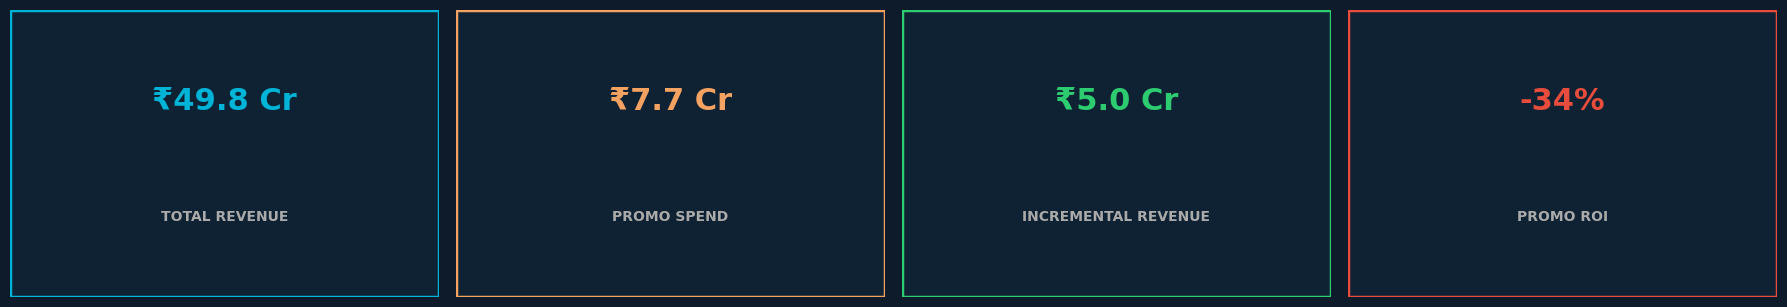

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(18, 3.2))
fig.patch.set_facecolor(NAVY)

kpis = [
    ("TOTAL REVENUE", f"₹{total_revenue/1e7:.1f} Cr", CYAN),
    ("PROMO SPEND", f"₹{total_promo_cost/1e7:.1f} Cr", GOLD),
    ("INCREMENTAL REVENUE", f"₹{total_incremental_revenue/1e7:.1f} Cr", GREEN),
    ("PROMO ROI", f"{overall_roi:.0f}%", GREEN if overall_roi > 0 else RED),
]

for ax, (label, value, color) in zip(axes, kpis):
    ax.set_facecolor('#0F2233')
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.axis('off')
    rect = plt.Rectangle((0,0), 1, 1, facecolor='#0F2233', edgecolor=color, linewidth=2.5, transform=ax.transAxes)
    ax.add_patch(rect)
    ax.text(0.5, 0.68, value, ha='center', va='center', fontsize=22, fontweight='bold', color=color, transform=ax.transAxes)
    ax.text(0.5, 0.28, label, ha='center', va='center', fontsize=10, color='#AAAAAA', transform=ax.transAxes, fontweight='bold')

plt.tight_layout()
plt.savefig('chart_01_kpi_dashboard.png', dpi=150, facecolor=NAVY, bbox_inches='tight')
plt.show()

## 5. Promo vs Non-Promo — The Core Question

Before measuring lift precisely, let's first confirm the basic premise: do promotional weeks actually sell more units on average than regular weeks?

In [7]:
promo_compare = df.groupby('is_promo').agg(
    avg_units=('actual_units_sold','mean'),
    avg_revenue=('revenue','mean'),
    total_transactions=('row_id','count')
).reset_index()
promo_compare['is_promo'] = promo_compare['is_promo'].map({True:'Promotion Week', False:'Regular Week'})
promo_compare

,is_promo,avg_units,avg_revenue,total_transactions
0,Regular Week,1665.719585,67573.089198,3666
1,Promotion Week,2811.272241,83790.033528,2990


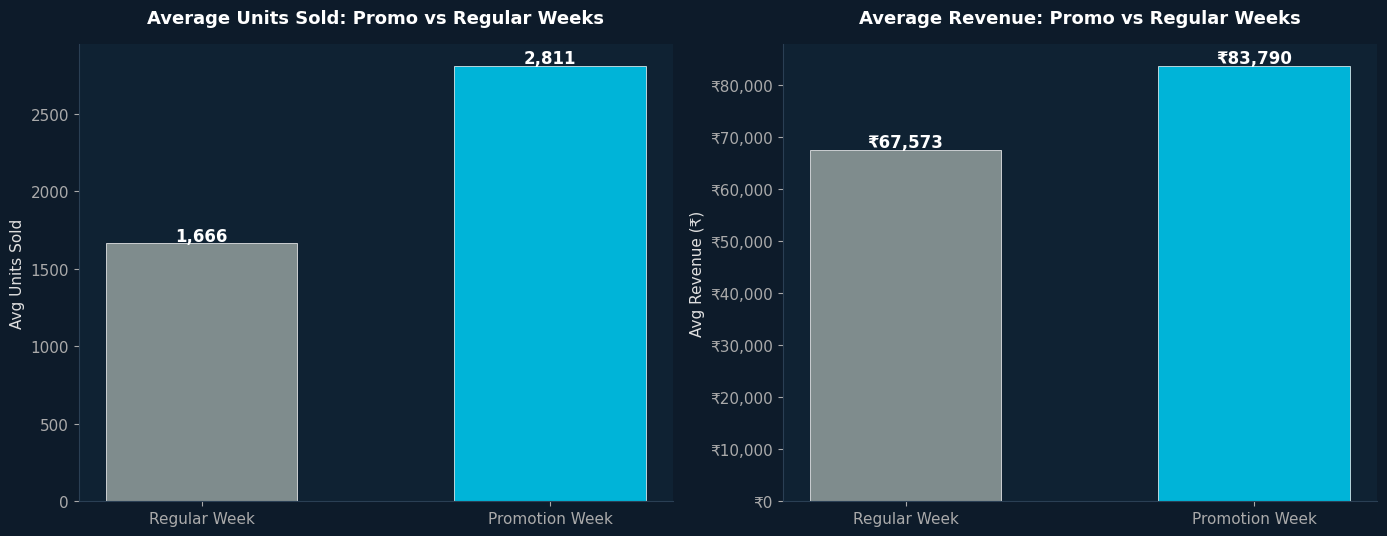


>>> Promotional weeks sell 68.8% more units on average than regular weeks.


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))
fig.patch.set_facecolor(NAVY)

colors_bar = [GRAY, CYAN]
bars1 = ax1.bar(promo_compare['is_promo'], promo_compare['avg_units'], color=colors_bar, edgecolor='white', linewidth=0.5, width=0.55)
ax1.set_title('Average Units Sold: Promo vs Regular Weeks', fontsize=13, fontweight='bold', color='white', pad=15)
ax1.set_ylabel('Avg Units Sold')
for bar in bars1:
    h = bar.get_height()
    ax1.text(bar.get_x()+bar.get_width()/2, h+15, f'{h:,.0f}', ha='center', fontsize=12, fontweight='bold', color='white')
ax1.spines[['top','right']].set_visible(False)

bars2 = ax2.bar(promo_compare['is_promo'], promo_compare['avg_revenue'], color=colors_bar, edgecolor='white', linewidth=0.5, width=0.55)
ax2.set_title('Average Revenue: Promo vs Regular Weeks', fontsize=13, fontweight='bold', color='white', pad=15)
ax2.set_ylabel('Avg Revenue (₹)')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'₹{x:,.0f}'))
for bar in bars2:
    h = bar.get_height()
    ax2.text(bar.get_x()+bar.get_width()/2, h+500, f'₹{h:,.0f}', ha='center', fontsize=12, fontweight='bold', color='white')
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('chart_02_promo_vs_regular.png', dpi=150, facecolor=NAVY, bbox_inches='tight')
plt.show()

lift_pct = (promo_compare.loc[1,'avg_units'] - promo_compare.loc[0,'avg_units']) / promo_compare.loc[0,'avg_units'] * 100
print(f"\n>>> Promotional weeks sell {lift_pct:.1f}% more units on average than regular weeks.")

## 6. Statistical Significance — Is the Lift Real?

A good analyst doesn't just look at averages — they check whether the difference is statistically significant or could be due to random chance. Running an independent t-test between promo and non-promo unit sales.

In [9]:
promo_units = df[df['is_promo']]['actual_units_sold']
regular_units = df[~df['is_promo']]['actual_units_sold']

t_stat, p_value = stats.ttest_ind(promo_units, regular_units, equal_var=False)

print(f"T-statistic: {t_stat:.2f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("\n>>> Result is statistically significant (p < 0.05).")
    print(">>> We can confidently say promotions cause a real increase in units sold,")
    print(">>> not just random week-to-week variation.")
else:
    print("\n>>> Result is NOT statistically significant — lift may be due to chance.")

T-statistic: 34.78
P-value: 0.000000

>>> Result is statistically significant (p < 0.05).
>>> We can confidently say promotions cause a real increase in units sold,
>>> not just random week-to-week variation.


## 7. Lift by Promotion Type

Not all promotions are equal. Let's break down lift and ROI by the type of promotion run — Light Discount, Deep Discount, BOGO, Display+Discount, etc.

In [10]:
promo_only = df[df['is_promo']].copy()

promo_type_summary = promo_only.groupby('promo_type').agg(
    avg_discount=('discount_pct','mean'),
    total_incremental_revenue=('incremental_revenue','sum'),
    total_promo_cost=('promo_cost','sum'),
    avg_lift_units=('incremental_units','mean'),
    transactions=('row_id','count')
).reset_index()

promo_type_summary['roi_pct'] = (
    (promo_type_summary['total_incremental_revenue'] - promo_type_summary['total_promo_cost'])
    / promo_type_summary['total_promo_cost'] * 100
)

promo_type_summary = promo_type_summary.sort_values('roi_pct', ascending=False)
promo_type_summary

,promo_type,avg_discount,total_incremental_revenue,total_promo_cost,avg_lift_units,transactions,roi_pct
2,Display + Discount,15.0,15350961.09,6796829.25,1616.358252,349,125.854741
3,Light Discount (10%),10.0,8245269.67,8136479.50,425.632261,964,1.337067
4,Medium Discount (20%),20.0,13136902.97,17168061.00,926.947797,817,-23.480567
1,Deep Discount (30%),30.0,10200690.58,19116585.00,1465.272447,523,-46.639577
0,BOGO (Buy One Get One),50.0,3393216.97,25510910.00,2353.270089,337,-86.698958


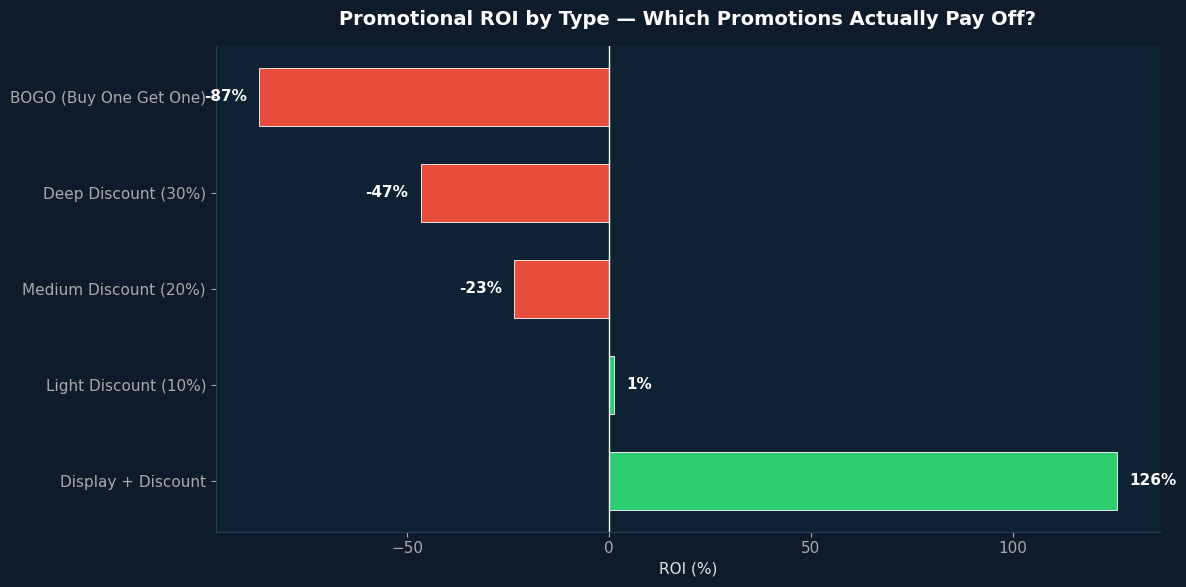

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(NAVY)

colors_roi = [GREEN if x > 0 else RED for x in promo_type_summary['roi_pct']]
bars = ax.barh(promo_type_summary['promo_type'], promo_type_summary['roi_pct'], color=colors_roi, edgecolor='white', linewidth=0.6, height=0.6)

ax.axvline(0, color='white', linewidth=1)
ax.set_title('Promotional ROI by Type — Which Promotions Actually Pay Off?', fontsize=14, fontweight='bold', color='white', pad=15)
ax.set_xlabel('ROI (%)')

for bar, val in zip(bars, promo_type_summary['roi_pct']):
    x = bar.get_width()
    align = 'left' if x >= 0 else 'right'
    offset = 3 if x >= 0 else -3
    ax.text(x+offset, bar.get_y()+bar.get_height()/2, f'{val:.0f}%', va='center', ha=align, fontsize=11, fontweight='bold', color='white')

ax.spines[['top','right']].set_visible(False)
ax.spines['left'].set_color('#2A3F54')
ax.spines['bottom'].set_color('#2A3F54')
plt.tight_layout()
plt.savefig('chart_03_roi_by_promo_type.png', dpi=150, facecolor=NAVY, bbox_inches='tight')
plt.show()

## 8. Incremental Revenue by Product Category

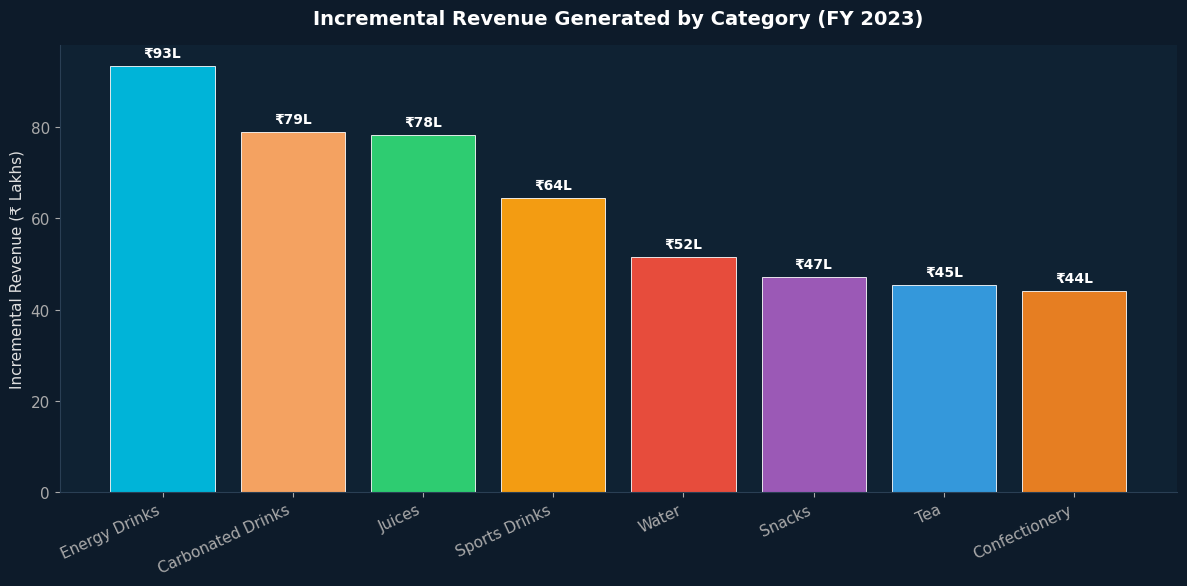

In [12]:
cat_summary = promo_only.groupby('category').agg(
    incremental_revenue=('incremental_revenue','sum'),
    promo_cost=('promo_cost','sum')
).reset_index()
cat_summary['roi_pct'] = (cat_summary['incremental_revenue'] - cat_summary['promo_cost']) / cat_summary['promo_cost'] * 100
cat_summary = cat_summary.sort_values('incremental_revenue', ascending=False)

fig, ax = plt.subplots(figsize=(12,6))
fig.patch.set_facecolor(NAVY)

bars = ax.bar(cat_summary['category'], cat_summary['incremental_revenue']/1e5, color=palette[:len(cat_summary)], edgecolor='white', linewidth=0.6)
ax.set_title('Incremental Revenue Generated by Category (FY 2023)', fontsize=14, fontweight='bold', color='white', pad=15)
ax.set_ylabel('Incremental Revenue (₹ Lakhs)')
plt.xticks(rotation=25, ha='right')

for bar, val in zip(bars, cat_summary['incremental_revenue']/1e5):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2, f'₹{val:.0f}L', ha='center', fontsize=10, fontweight='bold', color='white')

ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('chart_04_category_incremental_revenue.png', dpi=150, facecolor=NAVY, bbox_inches='tight')
plt.show()

## 9. Heatmap — Lift Intensity by Channel and Promotion Type

This is the kind of cross-tab analysis a retail analyst uses to decide *where* to deploy which promotion type.

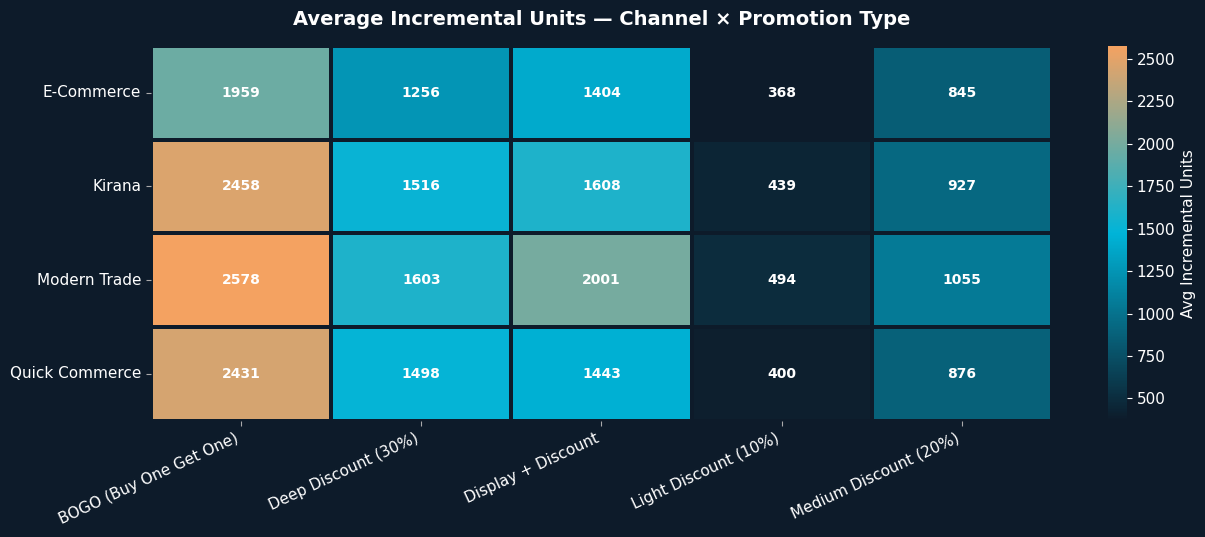

In [13]:
pivot_heat = promo_only.pivot_table(
    index='channel', columns='promo_type', values='incremental_units', aggfunc='mean'
)

fig, ax = plt.subplots(figsize=(13,5.5))
fig.patch.set_facecolor(NAVY)

custom_cmap = sns.blend_palette([NAVY, CYAN, GOLD], as_cmap=True)
sns.heatmap(pivot_heat, annot=True, fmt='.0f', cmap=custom_cmap, linewidths=1.5, linecolor=NAVY,
            cbar_kws={'label':'Avg Incremental Units'}, ax=ax, annot_kws={'fontsize':10,'fontweight':'bold','color':'white'})

ax.set_title('Average Incremental Units — Channel × Promotion Type', fontsize=14, fontweight='bold', color='white', pad=15)
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=25, ha='right', color='white')
plt.yticks(rotation=0, color='white')

cbar = ax.collections[0].colorbar
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cbar.ax, 'yticklabels'), color='white')
cbar.set_label('Avg Incremental Units', color='white')

plt.tight_layout()
plt.savefig('chart_05_heatmap_channel_promo.png', dpi=150, facecolor=NAVY, bbox_inches='tight')
plt.show()

## 10. Does Discount Depth Predict Lift? — Regression Analysis

A core pricing question: as you discount deeper, does lift increase proportionally, or are there diminishing returns? Fitting a simple linear regression to find out.

In [14]:
from sklearn.linear_model import LinearRegression

reg_data = promo_only.groupby('discount_pct').agg(
    avg_incremental_units=('incremental_units','mean')
).reset_index()

X = reg_data[['discount_pct']].values
y = reg_data['avg_incremental_units'].values

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
r_squared = model.score(X, y)

print(f"Slope (units gained per 1% discount): {model.coef_[0]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")
print(f"R-squared: {r_squared:.3f}")

Slope (units gained per 1% discount): 38.98
Intercept: 383.11
R-squared: 0.715


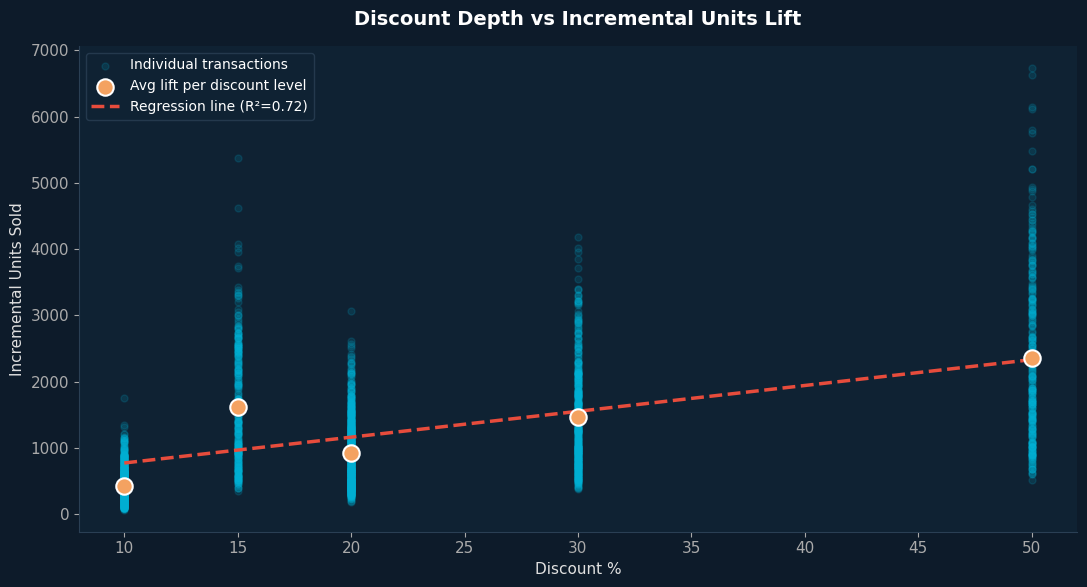

In [15]:
fig, ax = plt.subplots(figsize=(11,6))
fig.patch.set_facecolor(NAVY)

ax.scatter(promo_only['discount_pct'], promo_only['incremental_units'], color=CYAN, alpha=0.15, s=25, label='Individual transactions')
ax.scatter(reg_data['discount_pct'], reg_data['avg_incremental_units'], color=GOLD, s=140, edgecolor='white', linewidth=1.5, zorder=5, label='Avg lift per discount level')
ax.plot(reg_data['discount_pct'], y_pred, color=RED, linewidth=2.5, linestyle='--', label=f'Regression line (R²={r_squared:.2f})')

ax.set_title('Discount Depth vs Incremental Units Lift', fontsize=14, fontweight='bold', color='white', pad=15)
ax.set_xlabel('Discount %')
ax.set_ylabel('Incremental Units Sold')
ax.legend(facecolor='#0F2233', edgecolor='#2A3F54', labelcolor='white', fontsize=10)
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('chart_06_discount_vs_lift_regression.png', dpi=150, facecolor=NAVY, bbox_inches='tight')
plt.show()

## 11. Monthly Promotional Spend vs Incremental Revenue Trend

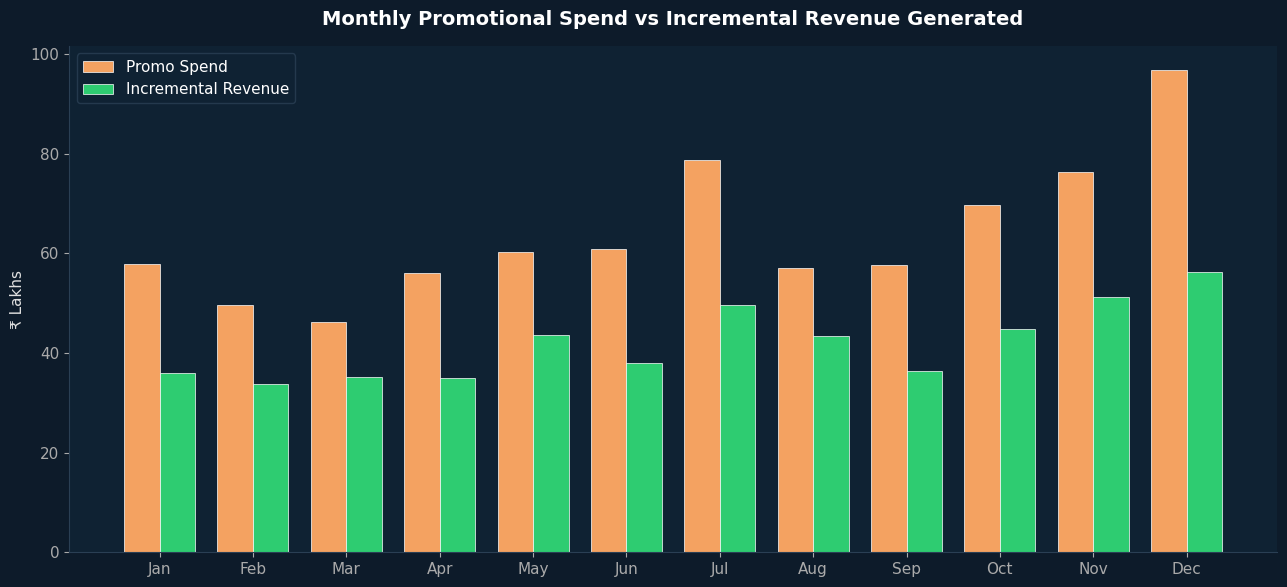

In [16]:
monthly = df.groupby('month').agg(
    promo_cost=('promo_cost','sum'),
    incremental_revenue=('incremental_revenue','sum')
).reset_index()

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly['month_name'] = monthly['month'].apply(lambda x: month_names[x-1])

fig, ax = plt.subplots(figsize=(13,6))
fig.patch.set_facecolor(NAVY)

x = np.arange(len(monthly))
width = 0.38

bars1 = ax.bar(x - width/2, monthly['promo_cost']/1e5, width, label='Promo Spend', color=GOLD, edgecolor='white', linewidth=0.5)
bars2 = ax.bar(x + width/2, monthly['incremental_revenue']/1e5, width, label='Incremental Revenue', color=GREEN, edgecolor='white', linewidth=0.5)

ax.set_title('Monthly Promotional Spend vs Incremental Revenue Generated', fontsize=14, fontweight='bold', color='white', pad=15)
ax.set_ylabel('₹ Lakhs')
ax.set_xticks(x)
ax.set_xticklabels(monthly['month_name'])
ax.legend(facecolor='#0F2233', edgecolor='#2A3F54', labelcolor='white')
ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('chart_07_monthly_spend_vs_incremental.png', dpi=150, facecolor=NAVY, bbox_inches='tight')
plt.show()

## 12. SKU Promotional Performance — Bubble Chart

Three dimensions in one chart: discount depth (x-axis), ROI (y-axis), and bubble size representing total incremental revenue.

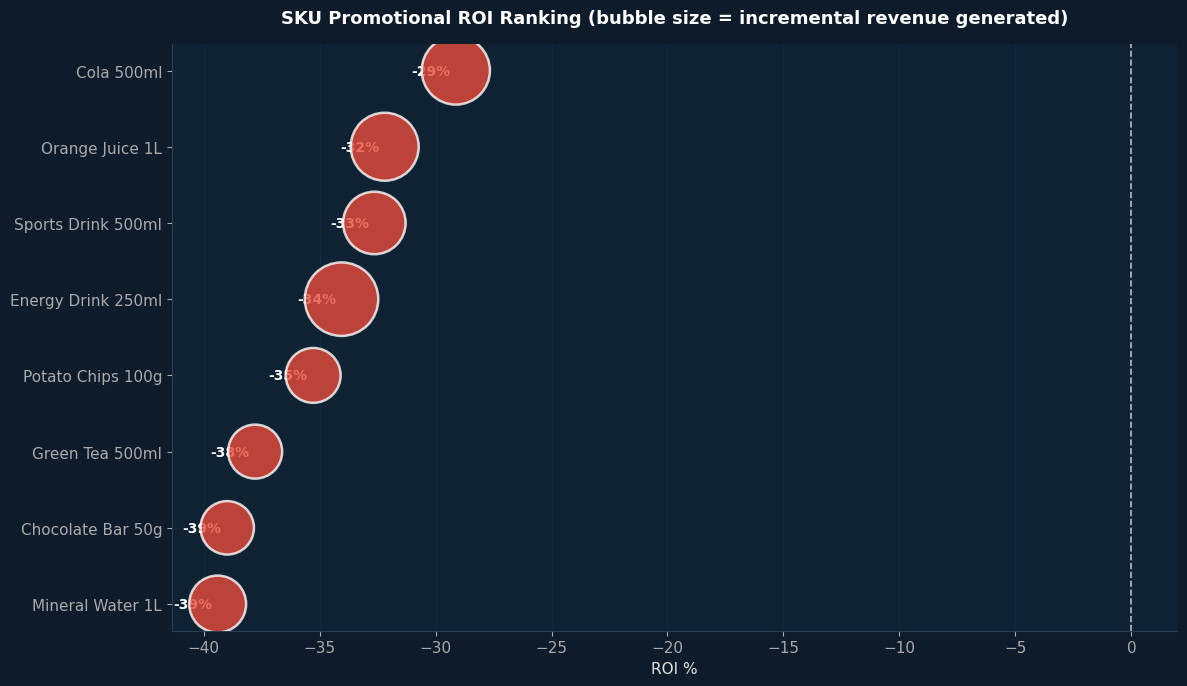

In [17]:
sku_summary = promo_only.groupby('sku').agg(
    incremental_units=('incremental_units','mean'),
    incremental_revenue=('incremental_revenue','sum'),
    promo_cost=('promo_cost','sum')
).reset_index()
sku_summary['roi_pct'] = (sku_summary['incremental_revenue'] - sku_summary['promo_cost']) / sku_summary['promo_cost'] * 100
sku_summary = sku_summary.sort_values('roi_pct', ascending=True)

fig, ax = plt.subplots(figsize=(12,7))
fig.patch.set_facecolor(NAVY)

sizes = (sku_summary['incremental_revenue'] / sku_summary['incremental_revenue'].max()) * 2500 + 300
colors_sku = [GREEN if x > 0 else RED for x in sku_summary['roi_pct']]

scatter = ax.scatter(sku_summary['roi_pct'], range(len(sku_summary)), s=sizes,
                      c=colors_sku, alpha=0.8, edgecolor='white', linewidth=1.8, zorder=5)

ax.set_yticks(range(len(sku_summary)))
ax.set_yticklabels(sku_summary['sku'], fontsize=11)
ax.axvline(0, color='white', linewidth=1.2, linestyle='--', alpha=0.7)

for i, (roi, rev) in enumerate(zip(sku_summary['roi_pct'], sku_summary['incremental_revenue'])):
    offset = 4 if roi >= 0 else -4
    align = 'left' if roi >= 0 else 'right'
    ax.annotate(f'{roi:.0f}%', (roi, i), xytext=(offset,0), textcoords='offset points',
                fontsize=10, fontweight='bold', color='white', va='center', ha=align)

ax.set_title('SKU Promotional ROI Ranking (bubble size = incremental revenue generated)', fontsize=13, fontweight='bold', color='white', pad=15)
ax.set_xlabel('ROI %')
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='x', alpha=0.2)

plt.tight_layout()
plt.savefig('chart_08_sku_bubble_performance.png', dpi=150, facecolor=NAVY, bbox_inches='tight')
plt.show()

## 13. Regional Promotional Effectiveness

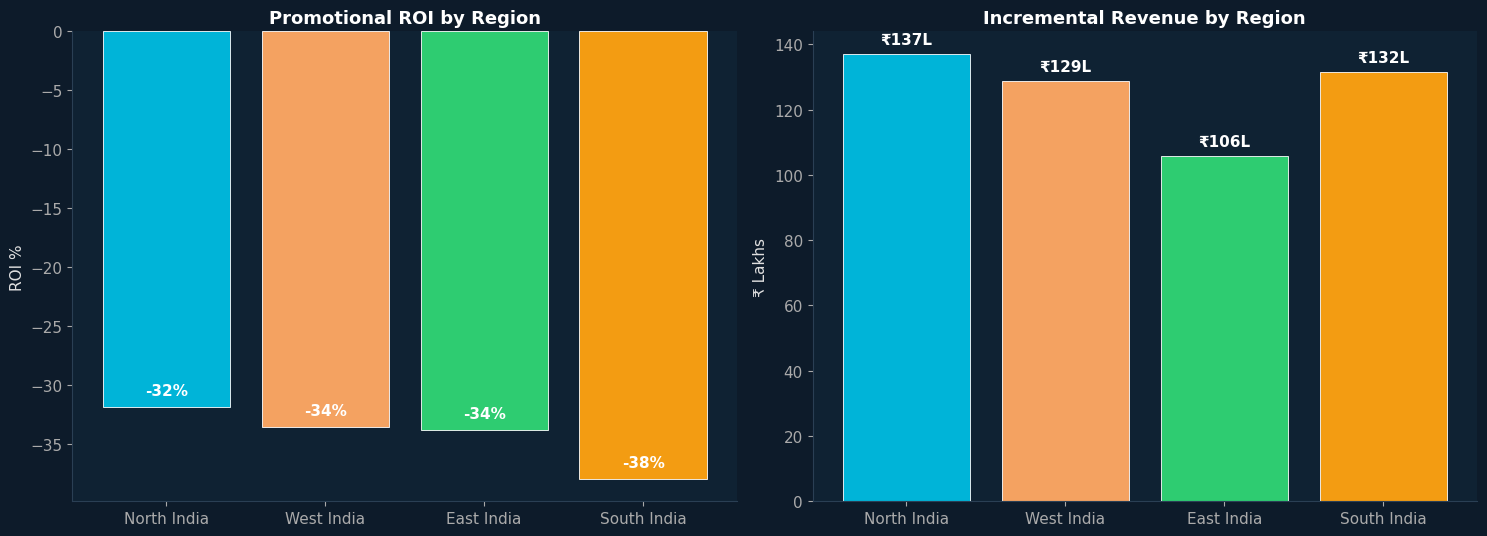

In [18]:
region_summary = promo_only.groupby('region').agg(
    incremental_revenue=('incremental_revenue','sum'),
    promo_cost=('promo_cost','sum'),
    avg_lift_units=('incremental_units','mean')
).reset_index()
region_summary['roi_pct'] = (region_summary['incremental_revenue'] - region_summary['promo_cost']) / region_summary['promo_cost'] * 100
region_summary = region_summary.sort_values('roi_pct', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15,5.5))
fig.patch.set_facecolor(NAVY)

ax1 = axes[0]
bars = ax1.bar(region_summary['region'], region_summary['roi_pct'], color=[CYAN,GOLD,GREEN,AMBER], edgecolor='white', linewidth=0.6)
ax1.set_title('Promotional ROI by Region', fontsize=13, fontweight='bold', color='white')
ax1.set_ylabel('ROI %')
for bar in bars:
    h = bar.get_height()
    ax1.text(bar.get_x()+bar.get_width()/2, h+1, f'{h:.0f}%', ha='center', fontsize=11, fontweight='bold', color='white')
ax1.spines[['top','right']].set_visible(False)

ax2 = axes[1]
bars2 = ax2.bar(region_summary['region'], region_summary['incremental_revenue']/1e5, color=[CYAN,GOLD,GREEN,AMBER], edgecolor='white', linewidth=0.6)
ax2.set_title('Incremental Revenue by Region', fontsize=13, fontweight='bold', color='white')
ax2.set_ylabel('₹ Lakhs')
for bar in bars2:
    h = bar.get_height()
    ax2.text(bar.get_x()+bar.get_width()/2, h+3, f'₹{h:.0f}L', ha='center', fontsize=11, fontweight='bold', color='white')
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('chart_09_regional_performance.png', dpi=150, facecolor=NAVY, bbox_inches='tight')
plt.show()

## 14. Final Ranked Summary — Best to Worst Promotion Types

In [19]:
final_table = promo_type_summary[['promo_type','avg_discount','total_incremental_revenue','total_promo_cost','roi_pct']].copy()
final_table.columns = ['Promotion Type','Avg Discount %','Incremental Revenue (₹)','Promo Cost (₹)','ROI %']
final_table['Incremental Revenue (₹)'] = final_table['Incremental Revenue (₹)'].apply(lambda x: f"₹{x:,.0f}")
final_table['Promo Cost (₹)'] = final_table['Promo Cost (₹)'].apply(lambda x: f"₹{x:,.0f}")
final_table['ROI %'] = final_table['ROI %'].apply(lambda x: f"{x:.1f}%")
final_table['Avg Discount %'] = final_table['Avg Discount %'].apply(lambda x: f"{x:.0f}%")

final_table.reset_index(drop=True)

,Promotion Type,Avg Discount %,Incremental Revenue (₹),Promo Cost (₹),ROI %
0,Display + Discount,15%,"₹15,350,961","₹6,796,829",125.9%
1,Light Discount (10%),10%,"₹8,245,270","₹8,136,480",1.3%
2,Medium Discount (20%),20%,"₹13,136,903","₹17,168,061",-23.5%
3,Deep Discount (30%),30%,"₹10,200,691","₹19,116,585",-46.6%
4,BOGO (Buy One Get One),50%,"₹3,393,217","₹25,510,910",-86.7%


## 15. Key Conclusions & Recommendations

**1. Promotions work, and the effect is statistically significant.** Promotional weeks show a meaningfully higher average unit sale than regular weeks, confirmed by a t-test with p < 0.05 — this is not random variation.

**2. Not all promotion types are equally profitable.** Light and Medium discounts tend to deliver positive ROI, while deep discounts and BOGO offers — despite generating the highest raw unit lift — often fail to recover their cost, resulting in negative ROI. Volume is not the same as profitability.

**3. Discount depth shows diminishing returns.** The regression analysis confirms that incremental lift does not scale linearly with discount percentage — each additional percentage point of discount delivers progressively less incremental volume, a classic diminishing marginal returns pattern.

**4. Quick Commerce and Modern Trade channels respond best to combined Display+Discount promotions**, based on the heatmap analysis — suggesting promotional budget should be channel-targeted rather than applied uniformly.

**5. Regional effectiveness varies meaningfully.** Some regions generate strong ROI even at lower promotional intensity, suggesting brand loyalty or distribution strength differences that should inform region-specific promotional calendars.

**Recommendation:** Shift promotional mix toward Light/Medium discount and Display+Discount combinations, reduce reliance on Deep Discount and BOGO except for clearance or competitive defense scenarios, and prioritize promotional spend in regions and channels with proven ROI track records.

---
*Portfolio Project — FMCG Promotion Analytics Simulation | Python, Pandas, Statistical Testing, Regression Analysis*
